# Customer 360 Azure Banking Analysis

This notebook uses pandas for local analysis and regenerates the CSV sample outputs under `data/sample_outputs`.

## Environment Setup

In [ ]:
%pip install pandas==2.2.2 numpy==1.26.4 matplotlib==3.9.0 scikit-learn==1.5.0 jupyter==1.0.0 notebook==7.2.1

In [2]:
from pathlib import Path
import sys

try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
except ModuleNotFoundError as exc:
    print(f"Missing package: {exc.name}")
    print(f"Notebook Python: {sys.executable}")
    print("Run the Environment Setup cell above, restart the kernel, then rerun this cell.")
    raise

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").exists() and (candidate / "requirements.txt").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing data/raw and requirements.txt")

PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
SAMPLE_DIR = PROJECT_ROOT / "data" / "sample_outputs"
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

customers = pd.read_csv(RAW_DIR / "customers.csv")
accounts = pd.read_csv(RAW_DIR / "accounts.csv")
cards = pd.read_csv(RAW_DIR / "credit_cards.csv")
loans = pd.read_csv(RAW_DIR / "loans.csv")
transactions = pd.read_csv(RAW_DIR / "transactions.csv")
branches = pd.read_csv(RAW_DIR / "branches.csv")

print("Project root:", PROJECT_ROOT)
print("Customers:", len(customers))
print("Accounts:", len(accounts))
print("Cards:", len(cards))
print("Loans:", len(loans))
print("Transactions:", len(transactions))
print("Branches:", len(branches))

Project root: /Users/vamshymetra/Downloads/customer-360-azure
Customers: 5000
Accounts: 8000
Cards: 2000
Loans: 1000
Transactions: 50000
Branches: 100


## Customer 360 Output

In [3]:
customer_360 = (
    customers
    .merge(accounts.groupby('customer_id').agg(account_count=('account_id','nunique'), total_account_balance=('account_balance','sum')).reset_index(), on='customer_id', how='left')
    .merge(cards.groupby('customer_id').agg(card_count=('card_id','nunique'), total_credit_limit=('credit_limit','sum')).reset_index(), on='customer_id', how='left')
    .merge(loans.groupby('customer_id').agg(loan_count=('loan_id','nunique'), total_loan_balance=('loan_balance','sum')).reset_index(), on='customer_id', how='left')
)

for col in ['account_count','total_account_balance','card_count','total_credit_limit','loan_count','total_loan_balance']:
    customer_360[col] = customer_360[col].fillna(0)

customer_360['total_products'] = customer_360['account_count'] + customer_360['card_count'] + customer_360['loan_count']
customer_360.to_csv(SAMPLE_DIR / 'gold_customer_360_sample.csv', index=False)
customer_360.head()

,customer_id,first_name,last_name,gender,age,email,phone_number,address,city,province,...,income_band,employment_status,created_date,account_count,total_account_balance,card_count,total_credit_limit,loan_count,total_loan_balance,total_products
0,CUST000001,Mason,Smith,M,65,mason.smith1@example.com,416-381-5012,3658 Queen St,Mississauga,NS,...,<50K,Unemployed,2023-04-02,2.0,3985.59,1.0,7500.0,0.0,0.0,3.0
1,CUST000002,Ava,Anderson,F,32,ava.anderson2@example.com,416-559-5557,107 Queen St,Montreal,BC,...,100K-150K,Unemployed,2022-07-07,3.0,19402.43,0.0,0.0,0.0,0.0,3.0
2,CUST000003,Aarav,Thomas,F,52,aarav.thomas3@example.com,416-227-7201,1292 Dundas St,Vancouver,NS,...,100K-150K,Employed,2022-11-14,1.0,12592.42,0.0,0.0,0.0,0.0,1.0
3,CUST000004,Liam,Martin,F,47,liam.martin4@example.com,416-750-6977,2665 Main St,Calgary,QC,...,50K-100K,Retired,2021-03-23,2.0,24664.80,0.0,0.0,0.0,0.0,2.0
4,CUST000005,Emma,Anderson,M,61,emma.anderson5@example.com,416-432-1916,3753 King St,Calgary,AB,...,150K+,Self-Employed,2022-07-06,2.0,14314.76,1.0,20000.0,0.0,0.0,3.0


## Rule-Based Fraud Risk Scoring

In [4]:
tx = transactions.copy()
tx['transaction_timestamp'] = pd.to_datetime(tx['transaction_timestamp'])
tx['transaction_date'] = tx['transaction_timestamp'].dt.date
tx['transaction_hour'] = tx['transaction_timestamp'].dt.hour
tx = tx.merge(customers[['customer_id','risk_tier','age','credit_score','customer_segment']], on='customer_id', how='left')

risky_merchants = ['crypto', 'gambling', 'foreign_cash', 'high_value_electronics']
tx['rule_high_amount'] = np.where(tx['transaction_amount'] >= 1000, 25, 0)
tx['rule_unusual_hour'] = np.where((tx['transaction_hour'] <= 5) | (tx['transaction_hour'] >= 23), 15, 0)
tx['rule_risky_merchant'] = np.where(tx['merchant_category'].isin(risky_merchants), 20, 0)
tx['rule_high_risk_customer'] = np.where(tx['risk_tier'] == 'High', 20, 0)
tx['rule_card_not_present'] = np.where(tx['is_card_present'] == 0, 10, 0)
tx['fraud_rule_score'] = tx[['rule_high_amount','rule_unusual_hour','rule_risky_merchant','rule_high_risk_customer','rule_card_not_present']].sum(axis=1)
tx['fraud_rule_band'] = np.select([tx['fraud_rule_score'] >= 60, tx['fraud_rule_score'] >= 30], ['High', 'Medium'], default='Low')

tx[['transaction_id','transaction_amount','merchant_category','risk_tier','fraud_rule_score','fraud_rule_band','fraud_label']].head()

,transaction_id,transaction_amount,merchant_category,risk_tier,fraud_rule_score,fraud_rule_band,fraud_label
0,TXN000000001,153.84,restaurant,Medium,25,Low,0
1,TXN000000002,247.91,retail,Low,0,Low,0
2,TXN000000003,37.76,high_value_electronics,Low,20,Low,0
3,TXN000000004,127.18,grocery,Medium,15,Low,0
4,TXN000000005,69.08,retail,Medium,15,Low,0


## Local ML Fraud Prediction Using scikit-learn

The production implementation in `src/gold.py` uses Spark ML. The notebook uses scikit-learn to keep local review simple.

In [5]:
import sys

try:
    import sklearn
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import classification_report
except ModuleNotFoundError as exc:
    print(f"Missing package: {exc.name}")
    print(f"Notebook Python: {sys.executable}")
    print("Install scikit-learn into this exact notebook kernel with:")
    print(f"{sys.executable} -m pip install scikit-learn==1.5.0")
    print("Or run the Environment Setup cell at the top, restart the kernel, and rerun this cell.")
    raise

print("Notebook Python:", sys.executable)
print("scikit-learn:", sklearn.__version__)

categorical_features = ["risk_tier", "merchant_category", "transaction_channel"]
numeric_features = ["transaction_amount", "transaction_hour", "age", "credit_score"]
features = numeric_features + categorical_features

X = tx[features].fillna({
    "risk_tier": "Unknown",
    "merchant_category": "Unknown",
    "transaction_channel": "Unknown",
    "age": 0,
    "credit_score": 0,
    "transaction_amount": 0,
    "transaction_hour": 0,
})
y = tx["fraud_label"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs")),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
model.fit(X_train, y_train)
tx["fraud_ml_probability"] = model.predict_proba(X)[:, 1]
tx["fraud_ml_prediction"] = (tx["fraud_ml_probability"] >= 0.50).astype(int)

print(classification_report(y_test, model.predict(X_test)))

Notebook Python: /opt/anaconda3/bin/python
scikit-learn: 1.5.0
              precision    recall  f1-score   support

           0       0.99      0.79      0.88     12264
           1       0.04      0.47      0.08       236

    accuracy                           0.78     12500
   macro avg       0.51      0.63      0.48     12500
weighted avg       0.97      0.78      0.86     12500



## Generate Gold Sample Outputs

In [6]:
daily_summary = tx.groupby('transaction_date').agg(
    transaction_count=('transaction_id','count'),
    total_transaction_amount=('transaction_amount','sum'),
    avg_rule_fraud_score=('fraud_rule_score','mean'),
    confirmed_fraud_count=('fraud_label','sum'),
    ml_predicted_fraud_count=('fraud_ml_prediction','sum')
).reset_index()

fraud_summary = tx.groupby(['fraud_rule_band','risk_tier','merchant_category']).agg(
    transaction_count=('transaction_id','count'),
    total_transaction_amount=('transaction_amount','sum'),
    confirmed_fraud_count=('fraud_label','sum'),
    avg_ml_fraud_probability=('fraud_ml_probability','mean'),
    avg_rule_score=('fraud_rule_score','mean')
).reset_index()

product_summary = customer_360.groupby(['customer_segment','risk_tier']).agg(
    customer_count=('customer_id','nunique'),
    avg_products_per_customer=('total_products','mean'),
    avg_account_balance=('total_account_balance','mean'),
    avg_loan_balance=('total_loan_balance','mean')
).reset_index()

branch_perf = accounts.merge(branches, on='branch_id', how='left').groupby(['branch_id','branch_name','city','province']).agg(
    customer_count=('customer_id','nunique'),
    account_count=('account_id','nunique'),
    total_deposit_balance=('account_balance','sum')
).reset_index()

daily_summary.to_csv(SAMPLE_DIR / 'gold_daily_transaction_summary_sample.csv', index=False)
fraud_summary.to_csv(SAMPLE_DIR / 'gold_fraud_risk_summary_sample.csv', index=False)
product_summary.to_csv(SAMPLE_DIR / 'gold_product_holding_summary_sample.csv', index=False)
branch_perf.to_csv(SAMPLE_DIR / 'gold_branch_performance_sample.csv', index=False)
tx.to_csv(SAMPLE_DIR / 'gold_transactions_scored_sample.csv', index=False)

print('Sample outputs regenerated under:', SAMPLE_DIR)

Sample outputs regenerated under: /Users/vamshymetra/Downloads/customer-360-azure/data/sample_outputs


## Visual Checks

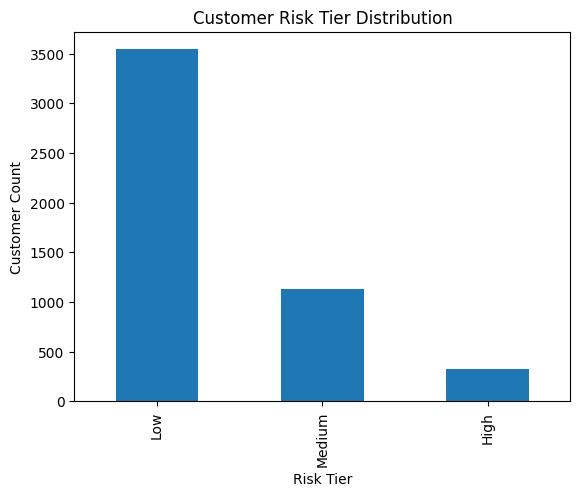

In [7]:
customers['risk_tier'].value_counts().plot(kind='bar', title='Customer Risk Tier Distribution')
plt.xlabel('Risk Tier')
plt.ylabel('Customer Count')
plt.show()

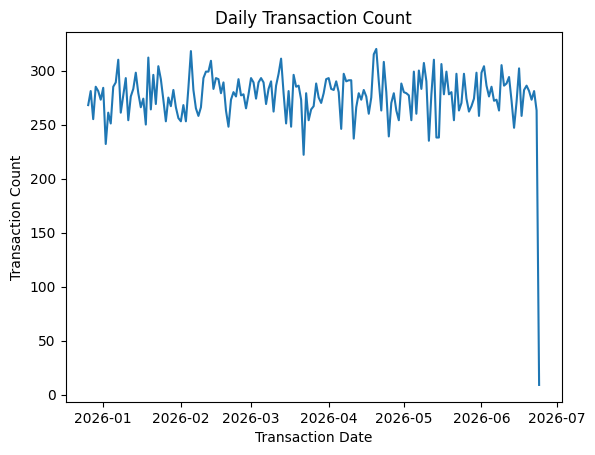

In [8]:
daily_summary.set_index('transaction_date')['transaction_count'].plot(title='Daily Transaction Count')
plt.xlabel('Transaction Date')
plt.ylabel('Transaction Count')
plt.show()

## Power BI Candidate Metrics

- Total customers
- Active customers
- Average products per customer
- Total deposits
- Total loan exposure
- High-risk transaction count
- Confirmed fraud count
- ML-predicted fraud count
- Fraud rate
- Branch-level deposit balance